In [ ]:
# =====================================
# STEP 0 : Reproducibility
# =====================================
import numpy as np
import pandas as pd
import random

np.random.seed(42)
random.seed(42)


In [ ]:
# =====================================
# STEP 1 : Imports
# =====================================
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


In [ ]:
# =====================================
# STEP 2 : Load Dataset
# =====================================
columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]

data = pd.read_csv("/content/drive/MyDrive/heart+disease/processed.cleveland.data", names=columns)

data.replace("?", np.nan, inplace=True)
data = data.astype(float)
data.fillna(data.median(), inplace=True)

data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

X = data.drop("target", axis=1).values
y = data["target"].values

In [ ]:
# =====================================
# STEP 3 : Train Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# STEP 4 : Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

dim = X_train.shape[1]

In [ ]:

# STEP 5 : Fitness Function (Improved)
# =====================================
def fitness_function(solution):

    selected = np.where(solution == 1)[0]

    if len(selected) == 0:
        return 0

    X_sel = X_train[:, selected]

    model = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', LogisticRegression(max_iter=500))
    ])

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = []

    for train_idx, val_idx in skf.split(X_sel, y_train):
        X_tr, X_val = X_sel[train_idx], X_sel[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        scores.append(accuracy_score(y_val, pred))

    acc = np.mean(scores)

    # Balanced penalty (less aggressive)
    feature_ratio = len(selected) / dim

    return 0.95 * acc + 0.05 * feature_ratio



In [ ]:

# =====================================
# STEP 6 : CSA
# =====================================
class CuckooSearch:

    def __init__(self, pop_size, dim, iterations):
        self.pop_size = pop_size
        self.dim = dim
        self.iterations = iterations

    def optimize(self):

        population = np.random.randint(2, size=(self.pop_size, self.dim))
        best_solution = population[0]
        best_score = 0

        for i in range(self.iterations):

            for j in range(self.pop_size):

                score = fitness_function(population[j])

                if score > best_score:
                    best_score = score
                    best_solution = population[j].copy()

            for j in range(self.pop_size):
                step = np.random.randint(self.dim)
                population[j][step] ^= 1

        return best_solution


In [ ]:


# =====================================
# STEP 7 : GGO
# =====================================
class GGO:

    def __init__(self, pop_size, dim, iterations):
        self.pop_size = pop_size
        self.dim = dim
        self.iterations = iterations

    def optimize(self):

        population = np.random.randint(2, size=(self.pop_size, self.dim))
        best_solution = population[0]
        best_score = 0

        for i in range(self.iterations):

            for j in range(self.pop_size):

                score = fitness_function(population[j])

                if score > best_score:
                    best_score = score
                    best_solution = population[j].copy()

            alpha = 0.5 * (1 - i/self.iterations)

            for j in range(self.pop_size):
                rand = np.random.rand(self.dim)
                population[j] = np.where(rand < alpha, best_solution, population[j])

        return best_solution

In [ ]:
# =====================================
# STEP 8 : Hybrid (BALANCED FIX)
# =====================================
class Hybrid:

    def __init__(self, pop_size, dim, iterations):
        self.pop_size = pop_size
        self.dim = dim
        self.iterations = iterations

    def optimize(self):

        csa = CuckooSearch(self.pop_size, self.dim, self.iterations//2)
        ggo = GGO(self.pop_size, self.dim, self.iterations//2)

        csa_best = csa.optimize()
        ggo_best = ggo.optimize()

        # 🔥 Balanced merge (NOT AND / NOT OR)
        hybrid = np.where(
            np.random.rand(self.dim) < 0.5,
            csa_best,
            ggo_best
        )

        return hybrid.astype(int)



In [ ]:
# =====================================
# STEP 9 : Feature Selection
# =====================================
hybrid = Hybrid(pop_size=30, dim=dim, iterations=30)
best_features = hybrid.optimize()

selected = np.where(best_features == 1)[0]

# Safety: ensure minimum features
if len(selected) < 5:
    selected = np.argsort(np.var(X_train, axis=0))[-5:]

print("Total Features:", dim)
print("Selected Features:", len(selected))

X_train_sel = X_train[:, selected]
X_test_sel = X_test[:, selected]


Total Features: 13
Selected Features: 10


In [ ]:
# =====================================
# STEP 10 : Final Model
# =====================================
final_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC(probability=True))
])

final_model.fit(X_train_sel, y_train)

pred = final_model.predict(X_test_sel)
prob = final_model.predict_proba(X_test_sel)[:,1]

In [ ]:
# STEP 11 : Evaluation
# =====================================
print("\nFinal Results")
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, prob))



Final Results
Accuracy : 0.8852459016393442
Precision: 0.8620689655172413
Recall   : 0.8928571428571429
F1 Score : 0.8771929824561403
ROC AUC  : 0.948051948051948


In [ ]:
# =====================================
# STEP 12 : Ablation Study
# =====================================
def evaluate(X_tr, X_te, y_tr, y_te):

    model = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', SVC(probability=True))
    ])

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    return accuracy_score(y_te, pred)


ablation = []

ablation.append(["No FS", evaluate(X_train, X_test, y_train, y_test)])
ablation.append(["Hybrid FS", evaluate(X_train_sel, X_test_sel, y_train, y_test)])

ablation_df = pd.DataFrame(ablation, columns=["Model", "Accuracy"])

print("\nAblation Study")
print(ablation_df)


Ablation Study
       Model  Accuracy
0      No FS  0.852459
1  Hybrid FS  0.885246


In [ ]:
# =====================================
# STEP 13 : MODEL COMPARISON
# =====================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Function to create pipeline (SMOTE + Model)
def build_pipeline(model):
    return Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

# WITHOUT FEATURE SELECTION
results_without = []

for name, model in models.items():

    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)

    results_without.append(acc)


# WITH HYBRID FEATURE SELECTION
results_with = []

for name, model in models.items():

    pipe = build_pipeline(model)
    pipe.fit(X_train_sel, y_train)

    pred = pipe.predict(X_test_sel)
    acc = accuracy_score(y_test, pred)

    results_with.append(acc)


# Create DataFrame
comparison_df = pd.DataFrame({
    "Model": list(models.keys()),
    "Without Feature Selection": results_without,
    "With Hybrid Feature Selection": results_with
})

print("\nModel Comparison Results")
print(comparison_df)




Model Comparison Results
               Model  Without Feature Selection  With Hybrid Feature Selection
0      Random Forest                   0.885246                       0.885246
1                SVM                   0.852459                       0.885246
2                KNN                   0.885246                       0.868852
3  Gradient Boosting                   0.852459                       0.852459


In [ ]:
from sklearn.ensemble import StackingClassifier

# Base models
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('svm', SVC(probability=True)),
    ('knn', KNeighborsClassifier())
]

# Stacking model
stack_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(),
        cv=5
    ))
])

# Train
stack_model.fit(X_train_sel, y_train)

# Predict
pred = stack_model.predict(X_test_sel)
prob = stack_model.predict_proba(X_test_sel)[:,1]

# Results
print("\nStacking Results")
print("Accuracy :", accuracy_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, prob))


Stacking Results
Accuracy : 0.8852459016393442
F1 Score : 0.8852459016393442
ROC AUC  : 0.9556277056277056


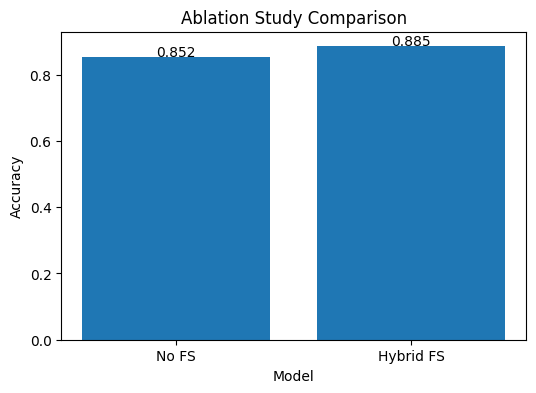

In [ ]:
# =====================================
# Ablation Study Graph
# =====================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(ablation_df["Model"], ablation_df["Accuracy"])

plt.title("Ablation Study Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, v in enumerate(ablation_df["Accuracy"]):
    plt.text(i, v + 0.002, str(round(v, 3)), ha='center')

plt.show()

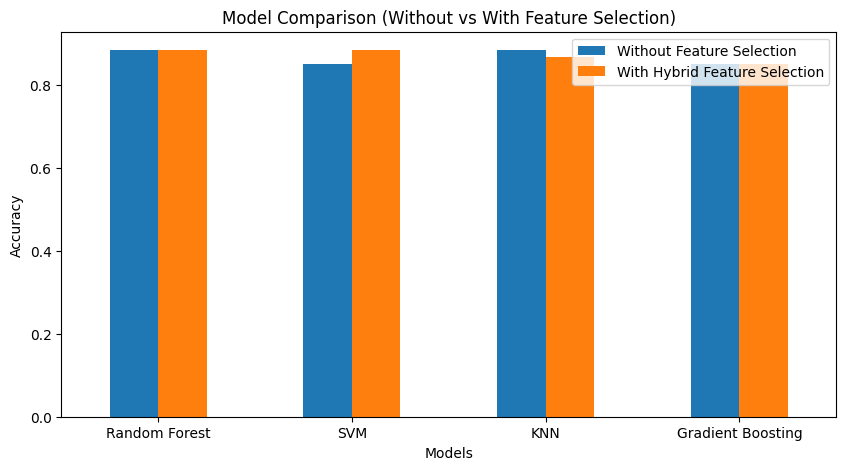

In [ ]:
# =====================================
# Model Comparison Graph
# =====================================

comparison_df.set_index("Model").plot(kind="bar", figsize=(10,5))

plt.title("Model Comparison (Without vs With Feature Selection)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.legend()

plt.show()

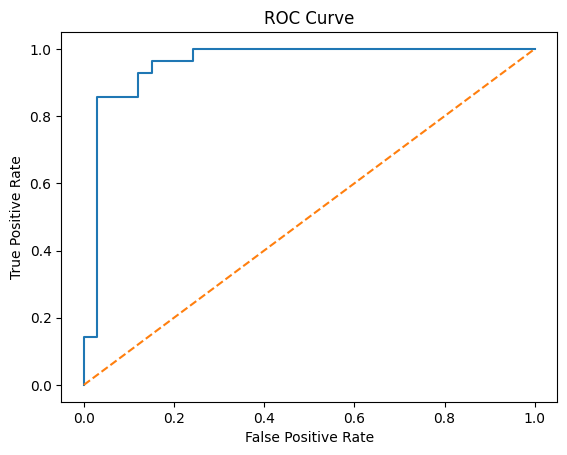

In [ ]:
# =====================================
# ROC Curve
# =====================================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

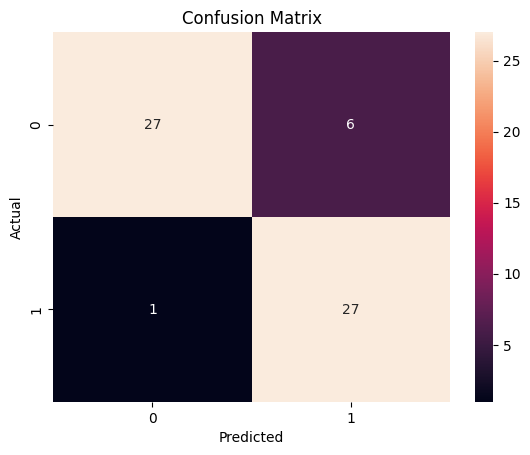

In [ ]:
# =====================================
# Confusion Matrix
# =====================================
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# =====================================
# Selected Feature Names
# =====================================
print("\nSelected Feature Index:", selected)
print("Selected Feature Names:", [columns[i] for i in selected])


Selected Feature Index: [ 0  1  2  3  5  7  8 10 11 12]
Selected Feature Names: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'thalach', 'exang', 'slope', 'ca', 'thal']


In [ ]:
# =====================================
# Stability Test (Multiple Runs)
# =====================================
runs = 10
acc_list = []

for i in range(runs):

    hybrid = Hybrid(pop_size=30, dim=dim, iterations=30)
    best_features = hybrid.optimize()

    selected = np.where(best_features == 1)[0]

    if len(selected) < 5:
        selected = np.argsort(np.var(X_train, axis=0))[-5:]

    X_train_sel = X_train[:, selected]
    X_test_sel = X_test[:, selected]

    model = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', SVC(probability=True))
    ])

    model.fit(X_train_sel, y_train)
    pred = model.predict(X_test_sel)

    acc = accuracy_score(y_test, pred)
    acc_list.append(acc)

print("\nStability Results")
print("Mean Accuracy:", np.mean(acc_list))
print("Std Deviation:", np.std(acc_list))


Stability Results
Mean Accuracy: 0.8163934426229508
Std Deviation: 0.04134268922268359
